# 6CS012 – Worksheet 5
## End-to-End CNN Model for Image Classification — Fruit in Amazon


## Mount Google Drive & Extract Dataset

---



In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/AI and Machine Learning/week5/FruitinAmazon.zip'
extract_path = '/content/FruitinAmazon'

if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall('/content/')
    print('Dataset extracted successfully.')
else:
    print('Dataset already extracted.')

train_dir = '/content/FruitinAmazon/train'
test_dir  = '/content/FruitinAmazon/test'

print('Train dir:', train_dir)
print('Test dir :', test_dir)

Dataset extracted successfully.
Train dir: /content/FruitinAmazon/train
Test dir : /content/FruitinAmazon/test


---
## Task 1: Data Understanding and Visualisation

### 1.1 — Load and Visualise One Sample Image per Class

In [4]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Get the list of class directories from the train folder
class_dirs = sorted([
    d for d in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, d))
])
print(f'Classes found ({len(class_dirs)}): {class_dirs}')

Classes found (6): ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


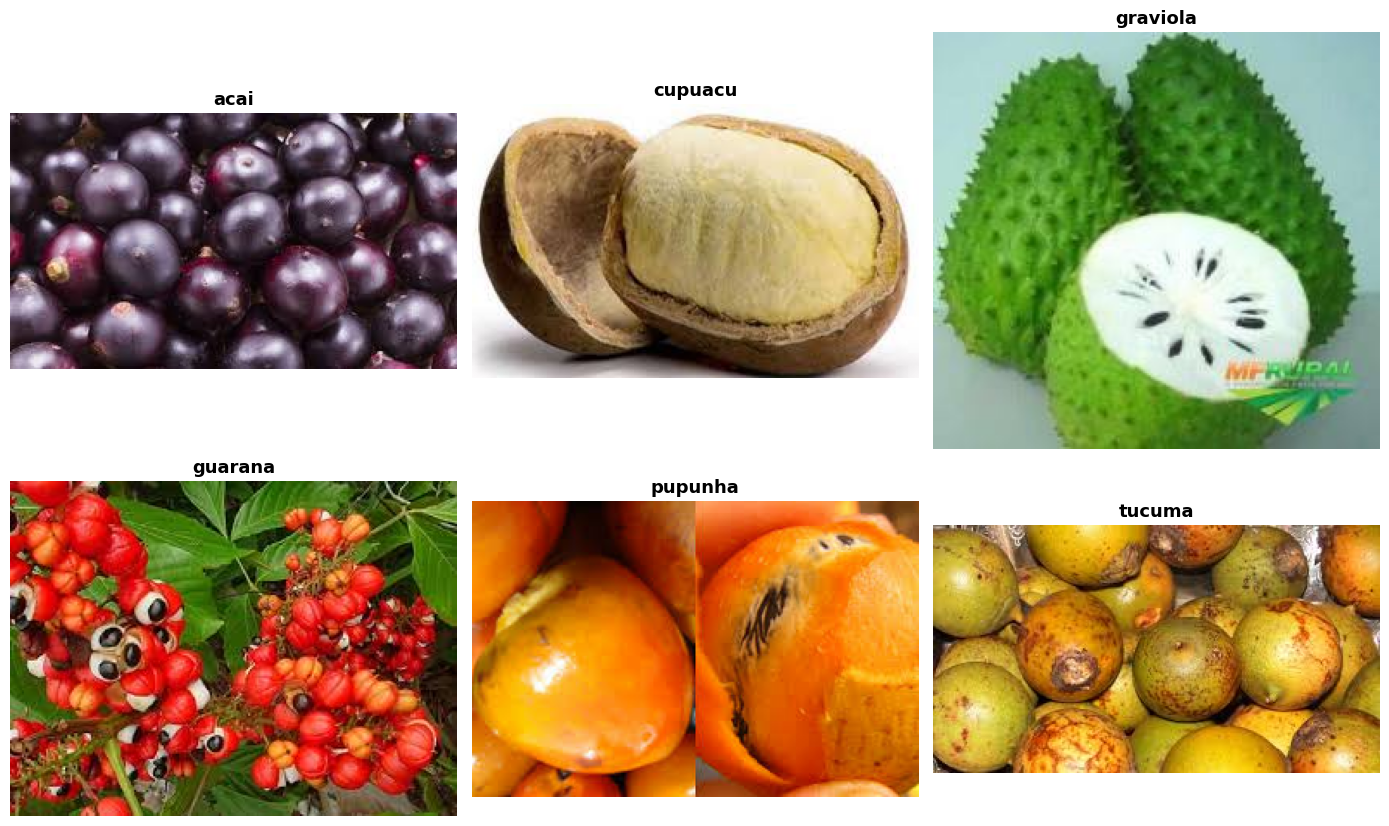

In [5]:
# Select one image randomly from each class
# Display in a grid format with two rows using matplotlib
cols = 3
rows = 2

fig, axes = plt.subplots(rows, cols, figsize=(14, 9))
axes = axes.flatten()

for idx, class_name in enumerate(class_dirs):
    class_path = os.path.join(train_dir, class_name)
    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]
    random_image = random.choice(images)
    img = mpimg.imread(os.path.join(class_path, random_image))
    axes[idx].imshow(img)
    axes[idx].set_title(class_name, fontsize=13, fontweight='bold')
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

**What did you Observe?**

- The dataset contains **6 Amazon fruit classes**: acai, cupuacu, graviola, guarana, pupunha, and tucuma.
- Images vary significantly in **background, lighting, angle, and zoom level**, which is typical of real-world web-scraped datasets.
- Some classes show fruits in clusters (e.g., *pupunha*, *tucuma*), while others show individual fruits (e.g., *graviola*, *cupuacu*) — this variation makes classification more challenging.
- All images are **colour (RGB)**, so the CNN input must handle 3 channels.

### 1.2 — Check for Corrupted Images

In [6]:
from PIL import Image

corrupted_images = []

for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)
    if not os.path.isdir(class_path):
        continue
    for image_file in os.listdir(class_path):
        image_path = os.path.join(class_path, image_file)
        try:
            with Image.open(image_path) as img:
                img.verify()
        except (IOError, SyntaxError):
            corrupted_images.append(image_path)
            os.remove(image_path)
            print(f'Removed corrupted image: {image_path}')

if not corrupted_images:
    print('No Corrupted Images Found.')
else:
    print(f'Total corrupted images removed: {len(corrupted_images)}')

No Corrupted Images Found.


---
## Task 2: Loading and Preprocessing Image Data in Keras

In [7]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

In [8]:
img_height       = 128
img_width        = 128
batch_size       = 16
validation_split = 0.2   # 80% training, 20% validation

In [9]:
# Create a preprocessing layer for normalisation
rescale = tf.keras.layers.Rescaling(1./255)  # Normalise pixel values to [0, 1]

In [10]:
# Create training dataset with normalisation
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels           = 'inferred',
    label_mode       = 'int',
    image_size       = (img_height, img_width),
    interpolation    = 'nearest',
    batch_size       = batch_size,
    shuffle          = True,
    validation_split = validation_split,
    subset           = 'training',
    seed             = 123
)
train_ds = train_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.


In [11]:
# Create validation dataset with normalisation
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels           = 'inferred',
    label_mode       = 'int',
    image_size       = (img_height, img_width),
    interpolation    = 'nearest',
    batch_size       = batch_size,
    shuffle          = False,
    validation_split = validation_split,
    subset           = 'validation',
    seed             = 123
)
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 18 files for validation.


In [12]:
# Create test dataset
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels        = 'inferred',
    label_mode    = 'int',
    image_size    = (img_height, img_width),
    interpolation = 'nearest',
    batch_size    = batch_size,
    shuffle       = False,
    seed          = 123
)
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

Found 30 files belonging to 6 classes.


In [13]:
class_names = class_dirs # Use the already available class_dirs variable
num_classes = len(class_names)
print('Class names:', class_names)
print('Num classes:', num_classes)

Class names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Num classes: 6


---
## Task 3: Implement the CNN Architecture

In [14]:
model = keras.Sequential([
    # Convolutional Block 1
    layers.Input(shape=(img_height, img_width, 3)),
    layers.Conv2D(32, (3, 3), padding='same', strides=(1, 1), activation='relu'),
    layers.MaxPooling2D((2, 2), strides=(2, 2)),

    # Convolutional Block 2
    layers.Conv2D(32, (3, 3), padding='same', strides=(1, 1), activation='relu'),
    layers.MaxPooling2D((2, 2), strides=(2, 2)),

    # Fully Connected Head
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(64,  activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,222 (16.07 MB)

 Trainable params: 4,213,222 (16.07 MB)

 Non-trainable params: 0 (0.00 B)

---
## Task 4: Compile the Model

In [16]:
model.compile(
    optimizer = 'adam',
    loss      = 'sparse_categorical_crossentropy',  # labels are integers
    metrics   = ['accuracy']
)

---
## Task 4: Train the Model

In [17]:
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    filepath       = 'best_fruit_model.h5',
    monitor        = 'val_accuracy',
    save_best_only = True,
    mode           = 'max',
    verbose        = 1
)

early_stop_cb = tf.keras.callbacks.EarlyStopping(
    monitor              = 'val_loss',
    patience             = 20,
    restore_best_weights = True,
    verbose              = 1
)

In [18]:
history = model.fit(
    train_ds,
    epochs          = 250,
    batch_size      = 16,
    validation_data = val_ds,
    callbacks       = [checkpoint_cb, early_stop_cb]
)

Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step - accuracy: 0.0802 - loss: 2.2296
Epoch 1: val_accuracy improved from None to 0.77778, saving model to best_fruit_model.h5



Epoch 1: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 418ms/step - accuracy: 0.0833 - loss: 2.2269 - val_accuracy: 0.7778 - val_loss: 1.4799
Epoch 2/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step - accuracy: 0.2750 - loss: 1.7121
Epoch 2: val_accuracy did not improve from 0.77778
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 366ms/step - accuracy: 0.2917 - loss: 1.6738 - val_accuracy: 0.1667 - val_loss: 1.6335
Epoch 3/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step - accuracy: 0.3937 - loss: 1.5262
Epoch 3: val_accuracy did not improve from 0.77778
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 348ms/step - accuracy: 0.4583 - loss: 1.4823 - val_accuracy: 0.3889 - val_loss: 1.4762
Epoch 4/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step - accuracy: 0.6024 - loss: 1.2040
Epoch 4: val_accuracy did not improve from 0.77778
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 340ms/step - accuracy: 0.6111 - loss: 1.1620 - val_accuracy: 0.6667 - val_loss: 1.1267
Epoch 5/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 441ms/step - accuracy: 0.8594 - loss:


Epoch 7: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 374ms/step - accuracy: 0.9028 - loss: 0.3666 - val_accuracy: 0.8333 - val_loss: 0.4349
Epoch 8/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step - accuracy: 0.9375 - loss: 0.1939
Epoch 8: val_accuracy did not improve from 0.83333
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 328ms/step - accuracy: 0.9167 - loss: 0.2329 - val_accuracy: 0.8333 - val_loss: 0.4364
Epoch 9/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step - accuracy: 0.9941 - loss: 0.1102
Epoch 9: val_accuracy did not improve from 0.83333
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 334ms/step - accuracy: 0.9861 - loss: 0.1258 - val_accuracy: 0.8333 - val_loss: 0.3915
Epoch 10/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step - accuracy: 0.9837 - loss: 0.0798
Epoch 10: val_accuracy did not improve from 0.83333
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 362ms/step - accuracy: 0.9861 - loss: 0.0718 - val_accuracy: 0.8333 - val_loss: 0.3669
Epoch 11/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 472ms/step - accuracy: 1.0000 - lo

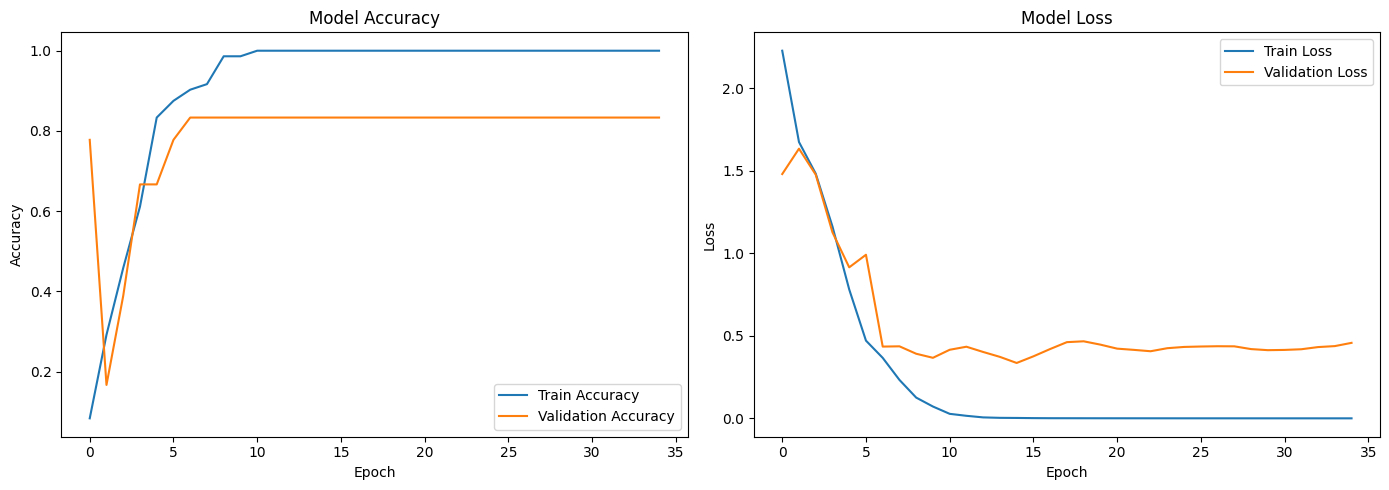

In [19]:
# Plot training & validation accuracy and loss
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],     label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'],     label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## Task 5: Evaluate the Model

In [20]:
test_loss, test_acc = model.evaluate(test_ds)
print(f'Test accuracy: {test_acc:.4f}')
print(f'Test loss    : {test_loss:.4f}')

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.7000 - loss: 0.7299
Test accuracy: 0.7000
Test loss    : 0.7299


---
## Task 6: Save and Load the Model

In [21]:
model.save('fruit_cnn_model.h5')
print('Model saved to fruit_cnn_model.h5')

Model saved to fruit_cnn_model.h5


In [22]:
loaded_model = tf.keras.models.load_model('fruit_cnn_model.h5')
print('Model loaded successfully.')

Model loaded successfully.


In [23]:
# Re-evaluate the loaded model on the test set
loaded_loss, loaded_acc = loaded_model.evaluate(test_ds)
print(f'Loaded model test accuracy: {loaded_acc:.4f}')

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - accuracy: 0.7000 - loss: 0.7299
Loaded model test accuracy: 0.7000


---
## Task 7: Predictions and Classification Report

In [24]:
# Collect all true labels and predictions from test set
y_true = []
y_pred_probs = []

for images, labels in test_ds:
    preds = loaded_model.predict(images, verbose=0)
    y_pred_probs.extend(preds)
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.argmax(np.array(y_pred_probs), axis=1)

print('Predicted labels:', [class_names[i] for i in y_pred[:5]])
print('Actual labels   :', [class_names[i] for i in y_true[:5]])

Predicted labels: ['acai', 'cupuacu', 'acai', 'acai', 'acai']
Actual labels   : ['acai', 'acai', 'acai', 'acai', 'acai']


In [25]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

        acai       0.57      0.80      0.67         5
     cupuacu       0.50      0.60      0.55         5
    graviola       0.83      1.00      0.91         5
     guarana       0.67      0.80      0.73         5
     pupunha       1.00      0.60      0.75         5
      tucuma       1.00      0.40      0.57         5

    accuracy                           0.70        30
   macro avg       0.76      0.70      0.69        30
weighted avg       0.76      0.70      0.69        30



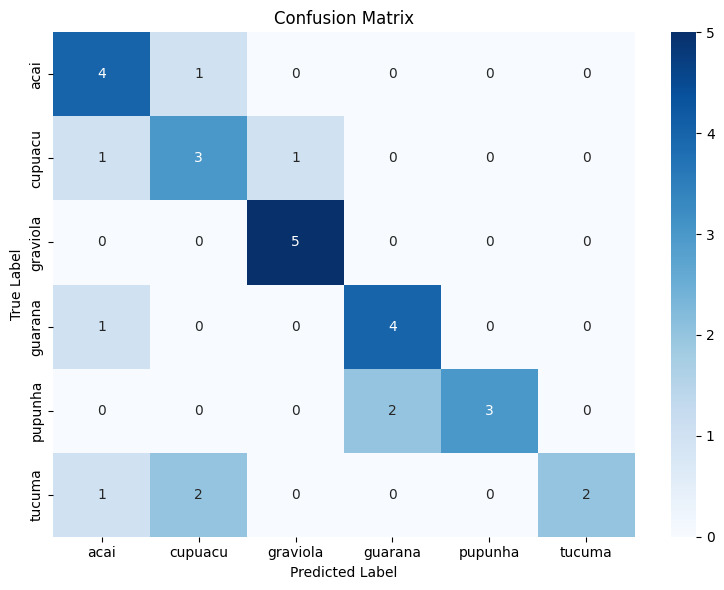

In [26]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()